# Model Training & Model Selection
**Project**: House Price Prediction  
**Notebook**: `04_Model_Training.ipynb`  
**Target**: Predict House `SalePrice` and compare 3 models (linear, tree-based, non-linear) using MAE, RMSE and $R^2$.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import TransformedTargetRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
print("All modeling libraries imported successfully!")

All modeling libraries imported successfully!


## 1. Load Preprocessed Feature Matrices

In [2]:
processed_dir = os.path.join("..", "data", "processed")
if not os.path.exists(processed_dir):
    processed_dir = os.path.join("data", "processed")

X_train = pd.read_csv(os.path.join(processed_dir, "X_train.csv"))
X_test = pd.read_csv(os.path.join(processed_dir, "X_test.csv"))
y_train = pd.read_csv(os.path.join(processed_dir, "y_train.csv")).values.ravel()
y_test = pd.read_csv(os.path.join(processed_dir, "y_test.csv")).values.ravel()

print("Datasets loaded successfully!")
print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape: ", y_test.shape)

Datasets loaded successfully!
X_train shape: (1164, 231)
X_test shape:  (292, 231)
y_train shape: (1164,)
y_test shape:  (292,)


## 2. Model Training

Three models, one per cell. All of them predict `log1p(SalePrice)` and convert back to dollars, which stabilises the skewed price distribution.

### Model 1 — Linear model: Ridge Regression

In [3]:
ridge_model = TransformedTargetRegressor(
    regressor=Ridge(alpha=10.0, random_state=42),
    func=np.log1p,
    inverse_func=np.expm1
)
ridge_model.fit(X_train, y_train)

ridge_pred_train = ridge_model.predict(X_train)
ridge_pred_test = ridge_model.predict(X_test)
print("Ridge Regression trained. Test R2:", round(r2_score(y_test, ridge_pred_test), 4))

Ridge Regression trained. Test R2: 0.9248


### Model 2 — Tree-based model: Random Forest

In [4]:
rf_model = TransformedTargetRegressor(
    regressor=RandomForestRegressor(n_estimators=300, max_depth=15, random_state=42, n_jobs=-1),
    func=np.log1p,
    inverse_func=np.expm1
)
rf_model.fit(X_train, y_train)

rf_pred_train = rf_model.predict(X_train)
rf_pred_test = rf_model.predict(X_test)
print("Random Forest trained. Test R2:", round(r2_score(y_test, rf_pred_test), 4))

Random Forest trained. Test R2: 0.8927


### Model 3 — Non-linear model: Support Vector Regressor (RBF kernel)

In [5]:
# SVR is distance-based, so the features are standardised inside the pipeline
svr_model = TransformedTargetRegressor(
    regressor=make_pipeline(StandardScaler(), SVR(kernel="rbf", C=10, epsilon=0.01, gamma="scale")),
    func=np.log1p,
    inverse_func=np.expm1
)
svr_model.fit(X_train, y_train)

svr_pred_train = svr_model.predict(X_train)
svr_pred_test = svr_model.predict(X_test)
print("SVR trained. Test R2:", round(r2_score(y_test, svr_pred_test), 4))

SVR trained. Test R2: 0.7816


## 3. Model Comparison

In [6]:
models = {
    "Ridge Regression (Linear)": ridge_model,
    "Random Forest (Tree-based)": rf_model,
    "SVR RBF (Non-linear)": svr_model,
}

results = []
for name, model in models.items():
    y_pred_tr = model.predict(X_train)
    y_pred_te = model.predict(X_test)

    results.append({
        "Model Name": name,
        "MAE": mean_absolute_error(y_test, y_pred_te),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_te)),
        "Train R2": r2_score(y_train, y_pred_tr),
        "Test R2": r2_score(y_test, y_pred_te),
    })

comparison_df = pd.DataFrame(results).sort_values(by="Test R2", ascending=False).reset_index(drop=True)
comparison_df

,Model Name,MAE,RMSE,Train R2,Test R2
0,Ridge Regression (Linear),14098.127567,19861.850330,0.948116,0.924836
1,Random Forest (Tree-based),16252.893460,23727.102272,0.984402,0.892734
2,SVR RBF (Non-linear),19799.296639,33854.177694,0.999343,0.781628


## 4. Visualize Test R² Score

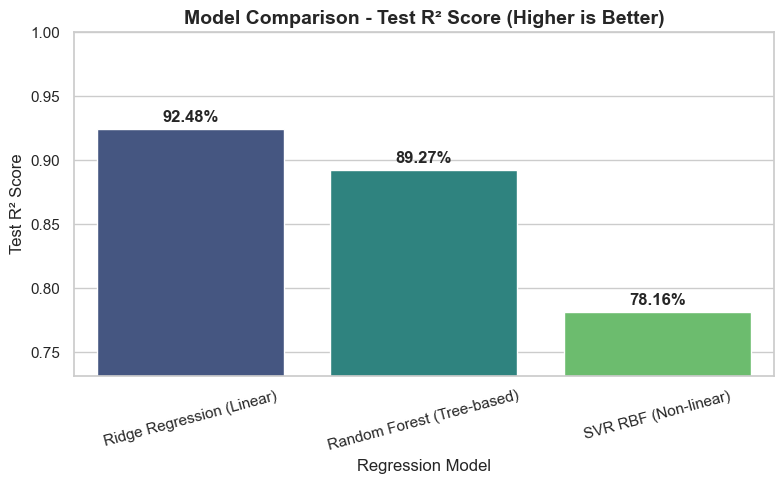

In [7]:
plt.figure(figsize=(8, 5))
sns.barplot(data=comparison_df, x="Model Name", y="Test R2", hue="Model Name", palette="viridis", legend=False)
plt.title("Model Comparison - Test R² Score (Higher is Better)", fontsize=14, fontweight="bold")
plt.xlabel("Regression Model", fontsize=12)
plt.ylabel("Test R² Score", fontsize=12)
plt.ylim(min(0.8, comparison_df["Test R2"].min() - 0.05), 1.0)
plt.xticks(rotation=15)

for idx, row in comparison_df.iterrows():
    plt.text(idx, row["Test R2"] + 0.005, f"{row['Test R2']*100:.2f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

## 5. Save Best Model Artifact

In [8]:
best_model_name = comparison_df.iloc[0]["Model Name"]
best_model_obj = models[best_model_name]

models_dir = os.path.join("..", "models")
if not os.path.exists(models_dir):
    models_dir = os.path.join("models")
os.makedirs(models_dir, exist_ok=True)

model_path = os.path.join(models_dir, "best_model.pkl")
joblib.dump(best_model_obj, model_path)

print(f"Best Performing Model ('{best_model_name}') saved to {model_path}!")

Best Performing Model ('Ridge Regression (Linear)') saved to ..\models\best_model.pkl!


## 6. Cross-Validation and Hyperparameter Optimization (Step 5)

In the previous section, we compared `ridge_model`, `rf_model` and `svr_model` using a **single train/test split**. This means we randomly divided our data once, trained on one part, and tested on the other. But what if we got lucky (or unlucky) with that specific split?

**Cross-validation** fixes this by testing each model multiple times on different parts of the data:

*   **K Folds**: We split our training data into "K" equal pieces (folds). For example, with $K=5$, we divide the data into 5 pieces.
*   **Rotation**: The model trains on 4 pieces and tests on the remaining 1 piece. This repeats 5 times, each time with a different piece used for testing.
*   **Trustworthy estimate**: Averaging the 5 scores gives a much more reliable estimate of how the model performs on unseen data than a single split does.

In [9]:
from sklearn.model_selection import KFold, cross_val_score, GridSearchCV

# We reuse the ridge_model, rf_model, svr_model and models dict already trained in Step 4 above.
# No need to reload the data or retrain them from scratch.

# We set up our cross-validation strategy: 5 folds, shuffle the data first, and set a random state for reproducibility
kf = KFold(n_splits=5, shuffle=True, random_state=42)

print("--- Cross-Validation Results (R2 Score) ---")

# We remember the average score of each model so we can automatically pick the best one afterwards
cv_mean_scores = {}

for model_name, model in models.items():
    # cross_val_score runs the model training and testing 5 times and returns the 5 scores.
    # We use X_train and y_train so we don't touch our final X_test/y_test test set yet.
    scores = cross_val_score(model, X_train, y_train, cv=kf, scoring="r2")

    print(f"\nModel: {model_name}")
    print(f"Scores for each of the 5 folds: {np.round(scores, 4)}")

    mean_score = scores.mean()
    std_score = scores.std()
    print(f"Average R2: {mean_score:.4f} (+/- {std_score:.4f})")

    cv_mean_scores[model_name] = mean_score

print("\n--- Summary of average scores ---")
for model_name, mean_score in cv_mean_scores.items():
    print(f"{model_name}: {mean_score:.4f}")

--- Cross-Validation Results (R2 Score) ---

Model: Ridge Regression (Linear)
Scores for each of the 5 folds: [0.9201 0.922  0.933  0.9175 0.9084]
Average R2: 0.9202 (+/- 0.0079)

Model: Random Forest (Tree-based)
Scores for each of the 5 folds: [0.889  0.8775 0.9039 0.8909 0.8757]
Average R2: 0.8874 (+/- 0.0102)

Model: SVR RBF (Non-linear)
Scores for each of the 5 folds: [0.8346 0.8273 0.8178 0.6731 0.8723]
Average R2: 0.8050 (+/- 0.0685)

--- Summary of average scores ---
Ridge Regression (Linear): 0.9202
Random Forest (Tree-based): 0.8874
SVR RBF (Non-linear): 0.8050


**Interpretation of Cross-Validation Results:**
*   **What does this result show?** 5 separate R² scores for each model, plus their average and standard deviation (stability).
*   **What can we learn from it?** Whether the models perform consistently across different slices of data. The model with the highest average R² is the best performer overall; the one with the lowest standard deviation is the most stable.
*   **Why is this useful?** It confirms whether the Step 4 single-split results were reliable, or just a lucky split.

---

## 7. Choose a Model and Optimize with GridSearchCV

Instead of guessing which model was best by eye, the code below automatically picks whichever model in `cv_mean_scores` has the **highest average cross-validation R²**. We store it as `cv_best_model_name` (kept separate from Step 4's `best_model_name`, which was chosen using the single train/test split — the two selections might not always agree).

**What is a hyperparameter?**
A hyperparameter is a "setting" of the algorithm chosen *before* training (e.g. `alpha` for Ridge, `n_estimators`/`max_depth` for Random Forest, `C`/`epsilon` for SVR). The model doesn't learn these values itself.

**What does `GridSearchCV` do?**
It tries every combination of hyperparameters we give it, evaluates each combination with cross-validation (same K-Fold idea as above), and keeps the best-performing combination.

Since our models are wrapped in `TransformedTargetRegressor`, every hyperparameter name in the grid needs a `regressor__` prefix (and, for SVR, an extra `svr__` because it also sits inside a `Pipeline`).

In [10]:
# We pick whichever model had the highest average cross-validation R2 score above
cv_best_model_name = max(cv_mean_scores, key=cv_mean_scores.get)
cv_best_model = models[cv_best_model_name]

print(f"Model selected for tuning (highest average CV R2): {cv_best_model_name}")

# A small, simple hyperparameter grid for each possible model.
# We only actually use the one that matches cv_best_model_name.
param_grids = {
    "Ridge Regression (Linear)": {
        "regressor__alpha": [1, 5, 10, 20]
    },
    "Random Forest (Tree-based)": {
        "regressor__n_estimators": [100, 300, 500],
        "regressor__max_depth": [10, 15, 20]
    },
    "SVR RBF (Non-linear)": {
        "regressor__svr__C": [1, 10, 50],
        "regressor__svr__epsilon": [0.01, 0.05, 0.1]
    }
}

param_grid = param_grids[cv_best_model_name]
print(f"Hyperparameter grid to test: {param_grid}")

print("\nSetting up GridSearchCV...")
grid_search = GridSearchCV(
    estimator=cv_best_model,
    param_grid=param_grid,
    cv=kf,
    scoring="r2",
    n_jobs=-1,
    verbose=1
)

print("Running GridSearchCV (this may take a few moments)...")
grid_search.fit(X_train, y_train)

print("\n--- Optimization Complete ---")
print(f"Best Hyperparameters Found: {grid_search.best_params_}")
print(f"Best Cross-Validation R2 Score: {grid_search.best_score_:.4f}")

best_tuned_model = grid_search.best_estimator_

Model selected for tuning (highest average CV R2): Ridge Regression (Linear)
Hyperparameter grid to test: {'regressor__alpha': [1, 5, 10, 20]}

Setting up GridSearchCV...
Running GridSearchCV (this may take a few moments)...
Fitting 5 folds for each of 4 candidates, totalling 20 fits

--- Optimization Complete ---
Best Hyperparameters Found: {'regressor__alpha': 20}
Best Cross-Validation R2 Score: 0.9222


**Interpretation of GridSearchCV:**
*   **What does this result show?** The combination of settings that produced the highest average R² across our 5 cross-validation folds, for whichever model scored best above.
*   **What can we learn from it?** Whether the default settings from Step 4 were already close to optimal, or whether specific adjustments unlock better performance.
*   **Why is this useful?** We now have a tuned model, mathematically proven (via cross-validation) to be the best version of itself from the options we provided.

---

## 8. Compare Before vs After Optimization

Let's check whether tuning made a noticeable difference, by evaluating both the original (Step 4) version and the newly tuned version on the completely unseen **Test Set** (`X_test`, `y_test`).

--- Performance on Unseen Test Data ---


,Model Version,MAE,RMSE,R2 (Test)
0,Ridge Regression (Linear) (Before Tuning),14098.127567,19861.850330,0.924836
1,Ridge Regression (Linear) (After Tuning),14112.866750,19896.503238,0.924573


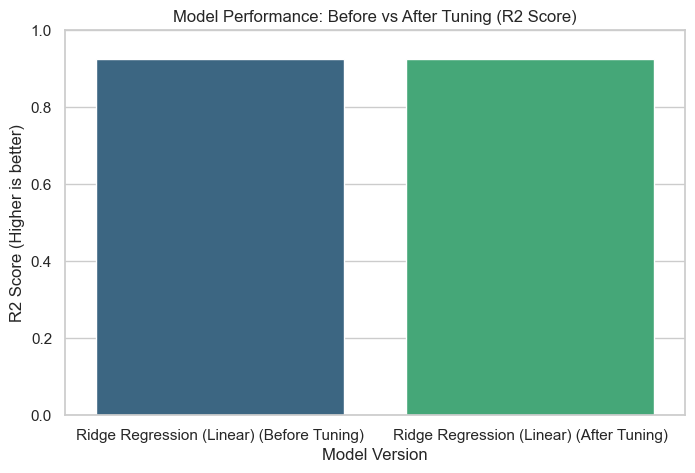

In [11]:
# 1. Predictions with the original model (before tuning, from Step 4)
y_pred_original = cv_best_model.predict(X_test)
mae_original = mean_absolute_error(y_test, y_pred_original)
rmse_original = np.sqrt(mean_squared_error(y_test, y_pred_original))
r2_original = r2_score(y_test, y_pred_original)

# 2. Predictions with the tuned model (after GridSearchCV)
y_pred_tuned = best_tuned_model.predict(X_test)
mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

# 3. Put the results in a simple Pandas DataFrame for easy comparison
comparison_before_after = pd.DataFrame({
    "Model Version": [f"{cv_best_model_name} (Before Tuning)", f"{cv_best_model_name} (After Tuning)"],
    "MAE": [mae_original, mae_tuned],
    "RMSE": [rmse_original, rmse_tuned],
    "R2 (Test)": [r2_original, r2_tuned]
})

print("--- Performance on Unseen Test Data ---")
display(comparison_before_after)

# 4. Simple bar chart to visualize the difference
plt.figure(figsize=(8, 5))
sns.barplot(
    x="Model Version",
    y="R2 (Test)",
    data=comparison_before_after,
    hue="Model Version",
    legend=False,
    palette="viridis"
)
plt.title("Model Performance: Before vs After Tuning (R2 Score)")
plt.ylabel("R2 Score (Higher is better)")
plt.xlabel("Model Version")
plt.ylim(0, 1.0)
plt.show()

## 10. Evaluation Visualizations — Best Model (Step 6)


In [12]:
# We reuse best_model_obj from Section 5 (the model already selected and saved to disk)
y_pred_best = best_model_obj.predict(X_test)

# The prediction error for every house: actual price minus predicted price
errors = y_test - y_pred_best

print(f"Using best model: {best_model_name}")
print(f"Number of test predictions: {len(y_pred_best)}")

Using best model: Ridge Regression (Linear)
Number of test predictions: 292


### Real vs Predicted Prices


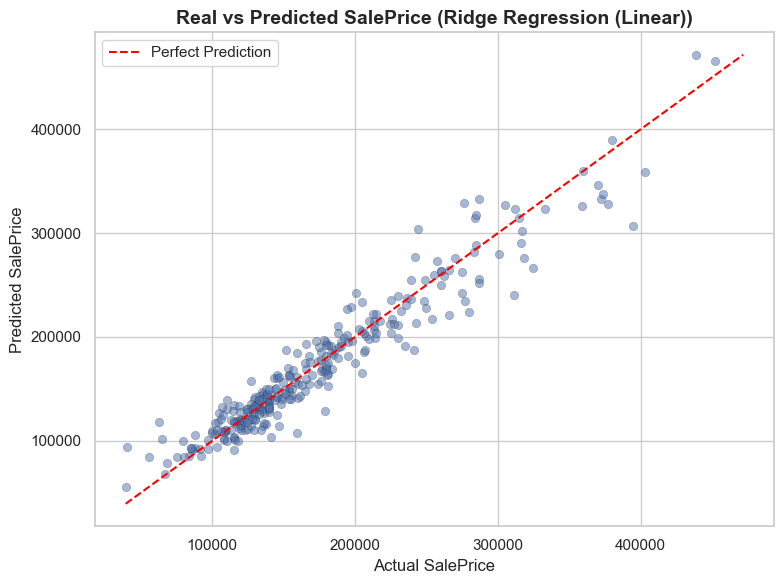

In [13]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.5, edgecolor="k", linewidth=0.3)

# Diagonal reference line: perfect predictions would fall exactly on this line
min_val = min(y_test.min(), y_pred_best.min())
max_val = max(y_test.max(), y_pred_best.max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Perfect Prediction")

plt.title(f"Real vs Predicted SalePrice ({best_model_name})", fontsize=14, fontweight="bold")
plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.legend()
plt.tight_layout()
plt.show()



### Distribution of Prediction Errors


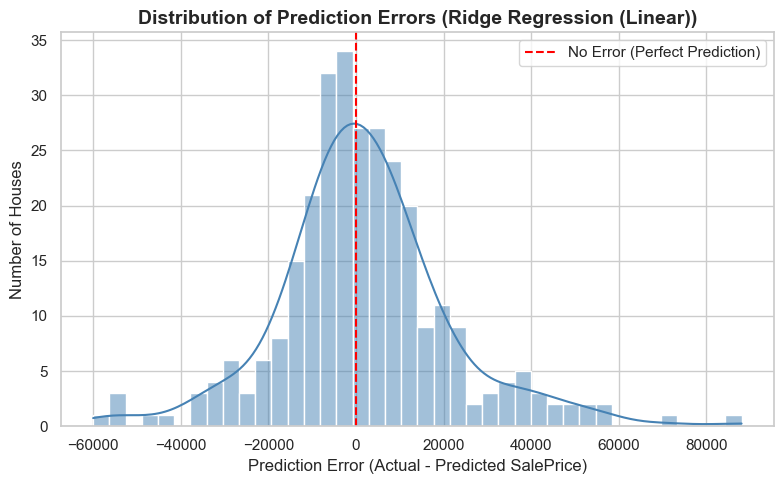

Mean error: 1875.29
Median error: 583.76


In [14]:
plt.figure(figsize=(8, 5))
sns.histplot(errors, bins=40, kde=True, color="steelblue")
plt.axvline(0, color="red", linestyle="--", label="No Error (Perfect Prediction)")

plt.title(f"Distribution of Prediction Errors ({best_model_name})", fontsize=14, fontweight="bold")
plt.xlabel("Prediction Error (Actual - Predicted SalePrice)")
plt.ylabel("Number of Houses")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mean error: {errors.mean():.2f}")
print(f"Median error: {np.median(errors):.2f}")


### Residual Analysis


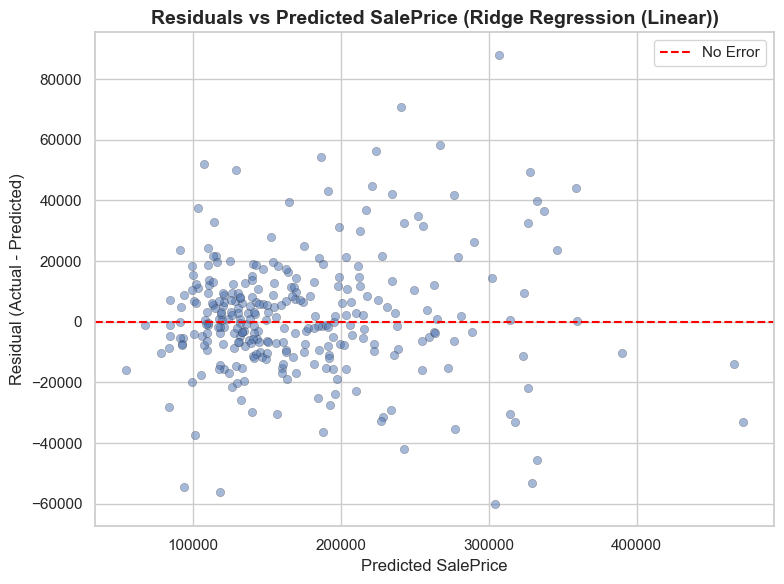

In [15]:
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_best, errors, alpha=0.5, edgecolor="k", linewidth=0.3)
plt.axhline(0, color="red", linestyle="--", label="No Error")

plt.title(f"Residuals vs Predicted SalePrice ({best_model_name})", fontsize=14, fontweight="bold")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual (Actual - Predicted)")
plt.legend()
plt.tight_layout()
plt.show()